In [2]:
import os
import torch
import numpy as np
from PIL import Image

def load_image(p):
    image = Image.open(p).convert("RGB")
    image = np.array(image)  # Shape: (H, W, 3)
    image = image.transpose(2,0,1)
    return image

d = '/mnt/share/Luigi/Documents/URAE/src/output/hpsv2_urae_original/anime'  # Directory containing images
imgs = [load_image(os.path.join(d, imgp)) for imgp in os.listdir(d) if imgp.endswith('.png')]
imgs = np.array(imgs)
imgs_pt = torch.from_numpy(imgs).unsqueeze(1)

In [24]:
import pickle
import numpy as np
import math
import torch
import einops
import matplotlib.pyplot as plt
from torch_dct import dct_2d, idct_2d

def zigzag_indices(n: int):
    """
    Returns a list of (row, col) indices following the *standard JPEG* zigzag:
      - Even diagonals (sum = 0,2,4,...) go bottom-up
      - Odd diagonals (sum = 1,3,5,...) go top-down
    """
    indices = []
    for s in range(2 * n - 1):
        if s % 2 == 0:
            # even sum => bottom-up
            for i in range(s, -1, -1):
                j = s - i
                if 0 <= i < n and 0 <= j < n:
                    indices.append((i, j))
        else:
            # odd sum => top-down
            for i in range(s + 1):
                j = s - i
                if 0 <= i < n and 0 <= j < n:
                    indices.append((i, j))
    return indices


def zigzag_flatten(block: torch.Tensor | np.ndarray) -> list:
    assert block.ndim == 2, f"Wrong shape for the block: {block.shape}"
    idx = zigzag_indices(block.shape[0])
    return [block[r][c] for (r, c) in idx]


def compute_dct_amplitude_spectrum(data, block_size=8, norm='ortho'):
    if isinstance(block_size, int):
        bh = bw = block_size
    else:
        bh, bw = block_size

    N, C, T, H, W = data.shape
    assert H % bh == 0 and W % bw == 0, "block_size must evenly divide H and W."

    # 1) Split into blocks of shape (bh, bw) using einops.rearrange
    blocks = einops.rearrange(data, pattern='n c t (h1 bh) (w1 bw) -> n c t h1 w1 bh bw', bh=bh, bw=bw)  # => [N, C, T, h_blocks, w_blocks, bh, bw]

    # 2) Apply 2D DCT on the last two axes
    dct_blocks = dct_2d(torch.from_numpy(blocks), norm=norm).numpy()

    # 3) Take the amplitude
    amp_blocks = np.abs(dct_blocks)

    # 4) Compute average amplitude across N, h_blocks, w_blocks => [C, T, bh, bw]
    avg_amplitude = einops.reduce(amp_blocks, pattern='n t c h1 w1 bh bw -> c t bh bw', reduction='mean')
    norm_amplitude = avg_amplitude / avg_amplitude[:, :, 0:1, 0:1]

    std_amplitude = torch.from_numpy(amp_blocks).std(dim=[0,3,4]).numpy()
    dc_std = std_amplitude[..., 0, 0]  # shape [C, T]
    norm_std = std_amplitude / dc_std[..., None, None]
    return avg_amplitude, std_amplitude, norm_amplitude, norm_std


def plot_spectrums_2d(spectrums, title=None, cmap='viridis'):
    """
    Plots a batch of 2D spectra on a roughly square grid with a single colorbar to the right.

    Args:
        spectrums: numpy array of shape [N, bh, bw].
        title: optional figure title.
        cmap: matplotlib colormap for imshow.
    """
    N, bh, bw = spectrums.shape
    grid_size = int(math.ceil(math.sqrt(N)))

    fig, axes = plt.subplots(grid_size, grid_size, figsize=(10, 10))
    axes = axes.flat if hasattr(axes, 'flat') else [axes]

    # Determine common color scale
    vmin, vmax = spectrums.min(), spectrums.max()

    # Plot each spectrum
    images = []
    for i, ax in enumerate(axes):
        if i < N:
            im = ax.imshow(spectrums[i], cmap=cmap, vmin=vmin, vmax=vmax)
            ax.set_title(f"Spectrum {i}")
            images.append(im)
        ax.axis('off')

    if title:
        fig.suptitle(title)

    # Make room on the right for a vertical colorbar
    plt.subplots_adjust(right=0.85)
    # Define a separate axis for the colorbar [left, bottom, width, height]
    cbar_ax = fig.add_axes([0.88, 0.15, 0.02, 0.7])
    # Use the last image (or any one of them) to draw a shared colorbar
    fig.colorbar(images[-1], cax=cbar_ax)

    plt.show()


def plot_spectrums_flat(
    blocks_dict,
    ylabel="Amplitude",
    title="DCT Zigzag Spectra",
    ncols_legend=1,
    plot_average=False,
    disable_color_grad: bool=False,
    font_size_scaler=1,
    save_path=None,
    figsize=(7,5),
    external_legend=False  # new parameter
):
    # Grab a representative item from the dictionary to determine shape
    first_blocks = next(iter(blocks_dict.values()))
    N, bh, bw = first_blocks.shape

    plt.style.use('default')
    plt.rcParams.update({
        'text.usetex': False,
        'font.family': 'serif',
        'font.serif': ['Times'],
        'font.size': int(14 * font_size_scaler),
        'axes.labelsize': int(14 * font_size_scaler),
        'axes.titlesize': int(18 * font_size_scaler),
        'xtick.labelsize': int(12 * font_size_scaler),
        'ytick.labelsize': int(12 * font_size_scaler),
    })

    # Compute zigzag indices and frequency array
    zigzag_idx = zigzag_indices(bh)  # presumably the same for all sets
    freqs = np.arange(bh * bw)

    # Set up figure and colormap
    plt.figure(figsize=figsize)
    colors = plt.cm.magma(np.linspace(0, 0.8, len(blocks_dict)))

    # Iterate over dictionary items (label -> blocks_3d)
    for (label, blocks_3d), color in zip(blocks_dict.items(), colors):
        color = None if disable_color_grad else color
        N, bh, bw = blocks_3d.shape
        all_zf = np.array([[blocks_3d[i, r, c] for r, c in zigzag_idx] for i in range(N)])

        if not plot_average:
            for i, zf in enumerate(all_zf):
                plt.plot(freqs, zf, linewidth=1, color=color, label=f"{label} Block{i}")
        else:
            all_zf = np.stack(all_zf, 0)
            m, s = all_zf.mean(axis=0), all_zf.std(axis=0)
            plt.plot(freqs, m, color=color, linewidth=2, label=label)
            plt.fill_between(freqs, m - s, m + s, color=color, alpha=0.15)

    plt.xlabel("Zigzag Frequency Index")
    plt.ylabel(ylabel)
    # plt.title(title)

    # Decide where the legend goes
    if external_legend:
        plt.legend(ncol=ncols_legend, bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
        plt.tight_layout(rect=[0, 0, 0.8, 1])  # shrink plot area to fit legend
    else:
        plt.legend(ncol=ncols_legend)
        plt.tight_layout()

    plt.grid(True)

    if save_path is not None:
        plt.savefig(save_path, format='pdf' if save_path.endswith('.pdf') else 'png', dpi=300, bbox_inches='tight')

    plt.show()


In [8]:
import shutil
def rename_model_files(checkpoint_path, model_subfolder=""):
    """
    Rename model files to the format expected by AutoencoderKL.
    
    Args:
        checkpoint_path: Path to the checkpoint directory
        model_subfolder: Subfolder within checkpoint where model is stored
    
    Returns:
        bool: True if files were renamed, False otherwise
    """
    # Check if model is in a subfolder
    dir_path = checkpoint_path
    if model_subfolder:
        potential_path = os.path.join(checkpoint_path, model_subfolder)
        if os.path.exists(potential_path):
            dir_path = potential_path
    
    # Check for model.safetensors and rename it
    source_file = os.path.join(dir_path, "model.safetensors")
    target_file = os.path.join(dir_path, "diffusion_pytorch_model.safetensors")
    
    if os.path.exists(source_file) and not os.path.exists(target_file):
        print(f"Renaming {source_file} to {target_file}")
        shutil.copy2(source_file, target_file)
        return True
    
    # Check for pytorch_model.bin and rename it
    source_file = os.path.join(dir_path, "pytorch_model.bin")
    target_file = os.path.join(dir_path, "diffusion_pytorch_model.bin")
    
    if os.path.exists(source_file) and not os.path.exists(target_file):
        print(f"Renaming {source_file} to {target_file}")
        shutil.copy2(source_file, target_file)
        return True
    
    return False
import os
import shutil

# Loop through checkpoint steps from 2000 to 20000 with step of 2000
for checkpoint_step in range(2000, 22000, 2000):
    checkpoint_path = f"/mnt/share/Luigi/Documents/URAE/src/vae_SE_finetuning/ckpt/vae_finetuned_LAION/checkpoint-{checkpoint_step}"
    
    print(f"Processing checkpoint at {checkpoint_path}")
    
    # Call the rename_model_files function for each checkpoint
    renamed = rename_model_files(checkpoint_path)
    
    if renamed:
        print(f"✅ Successfully renamed files in checkpoint-{checkpoint_step}")
    else:
        print(f"⚠️ No files needed renaming in checkpoint-{checkpoint_step}")

Processing checkpoint at /mnt/share/Luigi/Documents/URAE/src/vae_SE_finetuning/ckpt/vae_finetuned_LAION/checkpoint-2000
Renaming /mnt/share/Luigi/Documents/URAE/src/vae_SE_finetuning/ckpt/vae_finetuned_LAION/checkpoint-2000/model.safetensors to /mnt/share/Luigi/Documents/URAE/src/vae_SE_finetuning/ckpt/vae_finetuned_LAION/checkpoint-2000/diffusion_pytorch_model.safetensors
✅ Successfully renamed files in checkpoint-2000
Processing checkpoint at /mnt/share/Luigi/Documents/URAE/src/vae_SE_finetuning/ckpt/vae_finetuned_LAION/checkpoint-4000
Renaming /mnt/share/Luigi/Documents/URAE/src/vae_SE_finetuning/ckpt/vae_finetuned_LAION/checkpoint-4000/model.safetensors to /mnt/share/Luigi/Documents/URAE/src/vae_SE_finetuning/ckpt/vae_finetuned_LAION/checkpoint-4000/diffusion_pytorch_model.safetensors
✅ Successfully renamed files in checkpoint-4000
Processing checkpoint at /mnt/share/Luigi/Documents/URAE/src/vae_SE_finetuning/ckpt/vae_finetuned_LAION/checkpoint-6000
Renaming /mnt/share/Luigi/Docume

In [12]:
import os
import torch
import numpy as np
import pickle
from PIL import Image
from torch.utils.data import Dataset, DataLoader
from typing import Union, List, Tuple, Optional
from tqdm import tqdm
device = "cuda:1" if torch.cuda.is_available() else "cpu"
class ImageDataset(Dataset):
    def __init__(self, image_paths, transform=None):
        self.image_paths = image_paths
        self.transform = transform
        
    def __len__(self):
        return len(self.image_paths)
    
    def __getitem__(self, idx):
        image_path = self.image_paths[idx]
        image = Image.open(image_path).convert("RGB")
        if self.transform:
            image = self.transform(image)
        return image

def extract_and_save_latents(
    model_checkpoint_path: str,
    model_class,  # Your VAE model class
    image_dir: str,
    output_dir: str,
    batch_size: int = 32,
    latent_channels: int = 4,  # Number of channels in latent space
    latent_resolution: int = 32,  # Size of latent feature maps
    device: str = "cuda" if torch.cuda.is_available() else "cpu",
    image_transform = None,  # Your image transformation function
    image_extensions: List[str] = [".jpg", ".jpeg", ".png"],
    n_samples: Optional[int] = 1024  # Number of samples to process, None for all
):
    """
    Extract latent representations from a VAE checkpoint and save in format expected by ae-spectra.ipynb
    
    Args:
        model_checkpoint_path: Path to VAE model checkpoint
        model_class: Class of the VAE model
        image_dir: Directory containing images to encode
        output_dir: Directory to save latent representations
        batch_size: Batch size for processing
        latent_channels: Number of channels in latent space
        latent_resolution: Size of latent feature maps (assuming square)
        device: Device to use for computation
        image_transform: Transform to apply to images
        image_extensions: List of image file extensions to include
        n_samples: Number of samples to process (None for all)
    """
    # Create output directory if it doesn't exist
    os.makedirs(output_dir, exist_ok=True)
    
    # Load model checkpoint
    model = model_class.from_pretrained(model_checkpoint_path).to(device)
    model.eval()
            
    
    # Get image paths
    image_paths = []
    for root, _, files in os.walk(image_dir):
        for file in files:
            if any(file.lower().endswith(ext) for ext in image_extensions):
                image_paths.append(os.path.join(root, file))
    
    # Limit number of samples if specified
    if n_samples is not None and n_samples < len(image_paths):
        image_paths = image_paths[:n_samples]
    
    # Create dataset and dataloader
    dataset = ImageDataset(image_paths, transform=image_transform)
    dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=False, num_workers=4)
    
    all_features = []
    
    # Extract latent features
    with torch.no_grad():
        for batch in tqdm(dataloader, desc="Extracting latent features"):
            batch = batch.to(device)
            
            # This part depends on your model's encoder structure
            # Adjust according to your VAE implementation
            latent = model.encode(batch).latent_dist.sample()
                
            # Move to CPU and convert to numpy
            latent_np = latent.cpu().numpy()
            all_features.append(latent_np)
    
    # Create output filename
    model_name = os.path.basename(model_checkpoint_path)
    output_path = os.path.join(output_dir, f"{model_name}-full-n{len(image_paths)}.pkl")
    
    # Save latents in expected format
    latents_dict = {"all_features": all_features}
    with open(output_path, "wb") as f:
        pickle.dump(latents_dict, f)
    
    print(f"Saved latent features to {output_path}")
    print(f"Expected latent resolution for loading: (1, {latent_channels}, {latent_resolution}, {latent_resolution})")
    
    return output_path

# Example usage:
if __name__ == "__main__":
    # Import your VAE model class here
    from diffusers import AutoencoderKL
    
    # Define transform for your images
    from torchvision import transforms
    transform = transforms.Compose([
        transforms.Resize((256, 256)),
        transforms.ToTensor(),
        transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
    ])

    # Example usage (uncomment and modify)
    # Process checkpoints from 2000 to 20000 with step of 2000
    for checkpoint_step in range(2000, 22000, 2000):
        extract_and_save_latents(
            model_checkpoint_path=f"/mnt/share/Luigi/Documents/URAE/src/vae_SE_finetuning/ckpt/vae_finetuned_LAION/checkpoint-{checkpoint_step}",
            model_class=AutoencoderKL,
            image_dir="/mnt/share/Luigi/Documents/URAE/dataset/test_images",
            output_dir="/mnt/share/Luigi/Documents/URAE/src/vae_SE_finetuning/results/latents_for_spectral_analysis",
            batch_size=32,
            latent_channels=4,  # Adjust according to your model
            latent_resolution=32,  # Adjust according to your model
            image_transform=transform,
            device=device
        )
        print(f"Processed checkpoint at step {checkpoint_step}")

Extracting latent features: 100%|██████████| 1/1 [00:01<00:00,  1.82s/it]


Saved latent features to /mnt/share/Luigi/Documents/URAE/src/vae_SE_finetuning/results/latents_for_spectral_analysis/checkpoint-2000-full-n15.pkl
Expected latent resolution for loading: (1, 4, 32, 32)
Processed checkpoint at step 2000


Extracting latent features: 100%|██████████| 1/1 [00:01<00:00,  1.82s/it]


Saved latent features to /mnt/share/Luigi/Documents/URAE/src/vae_SE_finetuning/results/latents_for_spectral_analysis/checkpoint-4000-full-n15.pkl
Expected latent resolution for loading: (1, 4, 32, 32)
Processed checkpoint at step 4000


Extracting latent features: 100%|██████████| 1/1 [00:01<00:00,  1.81s/it]


...

Saved latent features to /mnt/share/Luigi/Documents/URAE/src/vae_SE_finetuning/results/latents_for_spectral_analysis/checkpoint-16000-full-n15.pkl
Expected latent resolution for loading: (1, 4, 32, 32)
Processed checkpoint at step 16000


Extracting latent features: 100%|██████████| 1/1 [00:02<00:00,  2.16s/it]


Saved latent features to /mnt/share/Luigi/Documents/URAE/src/vae_SE_finetuning/results/latents_for_spectral_analysis/checkpoint-18000-full-n15.pkl
Expected latent resolution for loading: (1, 4, 32, 32)
Processed checkpoint at step 18000


Extracting latent features: 100%|██████████| 1/1 [00:01<00:00,  1.95s/it]

Saved latent features to /mnt/share/Luigi/Documents/URAE/src/vae_SE_finetuning/results/latents_for_spectral_analysis/checkpoint-20000-full-n15.pkl
Expected latent resolution for loading: (1, 4, 32, 32)
Processed checkpoint at step 20000


In [22]:
import pickle
import os
import numpy as np

def load_latents(latents_path, latent_res: tuple[int]):
    with open(latents_path, 'rb') as f:
        latents = pickle.load(f)
    latents = np.concatenate([f.reshape(f.shape[0], *latent_res) for f in latents['all_features']], axis=0)

    return latents


# latents = {
#     "FluxAE-ch4": load_latents("/nfs/iskorokhodov/data/latents-stats/2926-snapshot-00100000.pt-full-n1024.pkl", latent_res=(1, 4, 32, 32)),
#     "FluxAE-ch8": load_latents("/nfs/iskorokhodov/data/latents-stats/2927-snapshot-00100000.pt-full-n1024.pkl", latent_res=(1, 8, 32, 32)),
#     "FluxAE-ch16": load_latents("/nfs/iskorokhodov/data/latents-stats/2929-snapshot-00100000.pt-full-n1024.pkl", latent_res=(1, 16, 32, 32)),
#     "FluxAE-ch24": load_latents('/nfs/iskorokhodov/data/latents-stats/2867-snapshot-00100000.pt-full-n1024.pkl', latent_res=(1, 24, 32, 32)),
#     "FluxAE-ch32": load_latents('/nfs/iskorokhodov/data/latents-stats/2868-snapshot-00100000.pt-full-n1024.pkl', latent_res=(1, 32, 32, 32)),
#     "FluxAE-ch48": load_latents('/nfs/iskorokhodov/data/latents-stats/2869-snapshot-00100000.pt-full-n1024.pkl', latent_res=(1, 48, 32, 32)),
#     "FluxAE-ch64": load_latents('/nfs/iskorokhodov/data/latents-stats/2870-snapshot-00100000.pt-full-n1024.pkl', latent_res=(1, 64, 32, 32)),
# }


with open("/mnt/share/Luigi/Documents/URAE/src/vae_SE_finetuning/results/latents_for_spectral_analysis/checkpoint-2000-full-n15.pkl", 'rb') as f:
    latents = pickle.load(f)
    print([f.shape for f in latents['all_features']])

latents={
    "VAE_2000": load_latents("/mnt/share/Luigi/Documents/URAE/src/vae_SE_finetuning/results/latents_for_spectral_analysis/checkpoint-2000-full-n15.pkl", latent_res=(1, 16, 32, 32)),
    "VAE_4000": load_latents("/mnt/share/Luigi/Documents/URAE/src/vae_SE_finetuning/results/latents_for_spectral_analysis/checkpoint-4000-full-n15.pkl", latent_res=(1, 16, 32, 32)),
    "VAE_6000": load_latents("/mnt/share/Luigi/Documents/URAE/src/vae_SE_finetuning/results/latents_for_spectral_analysis/checkpoint-6000-full-n15.pkl", latent_res=(1, 16, 32, 32)),
    "VAE_8000": load_latents("/mnt/share/Luigi/Documents/URAE/src/vae_SE_finetuning/results/latents_for_spectral_analysis/checkpoint-8000-full-n15.pkl", latent_res=(1, 16, 32, 32)),
    "VAE_10000": load_latents("/mnt/share/Luigi/Documents/URAE/src/vae_SE_finetuning/results/latents_for_spectral_analysis/checkpoint-10000-full-n15.pkl", latent_res=(1, 16, 32, 32)),
    "VAE_12000": load_latents("/mnt/share/Luigi/Documents/URAE/src/vae_SE_finetuning/results/latents_for_spectral_analysis/checkpoint-12000-full-n15.pkl", latent_res=(1, 16, 32, 32)),
    "VAE_14000": load_latents("/mnt/share/Luigi/Documents/URAE/src/vae_SE_finetuning/results/latents_for_spectral_analysis/checkpoint-14000-full-n15.pkl", latent_res=(1, 16, 32, 32)),
    "VAE_16000": load_latents("/mnt/share/Luigi/Documents/URAE/src/vae_SE_finetuning/results/latents_for_spectral_analysis/checkpoint-16000-full-n15.pkl", latent_res=(1, 16, 32, 32)),
    "VAE_18000": load_latents("/mnt/share/Luigi/Documents/URAE/src/vae_SE_finetuning/results/latents_for_spectral_analysis/checkpoint-18000-full-n15.pkl", latent_res=(1, 16, 32, 32)),
    "VAE_20000": load_latents("/mnt/share/Luigi/Documents/URAE/src/vae_SE_finetuning/results/latents_for_spectral_analysis/checkpoint-20000-full-n15.pkl", latent_res=(1, 16, 32, 32)),
}

block_size = 8
resolutions = {k: l.shape[-1] for k, l in latents.items()}
min_res = min(resolutions.values())
spectrums = {k: compute_dct_amplitude_spectrum(ls[:,[0]], block_size=block_size, norm='ortho') for k, ls in latents.items()}

[(15, 16, 32, 32)]


findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times


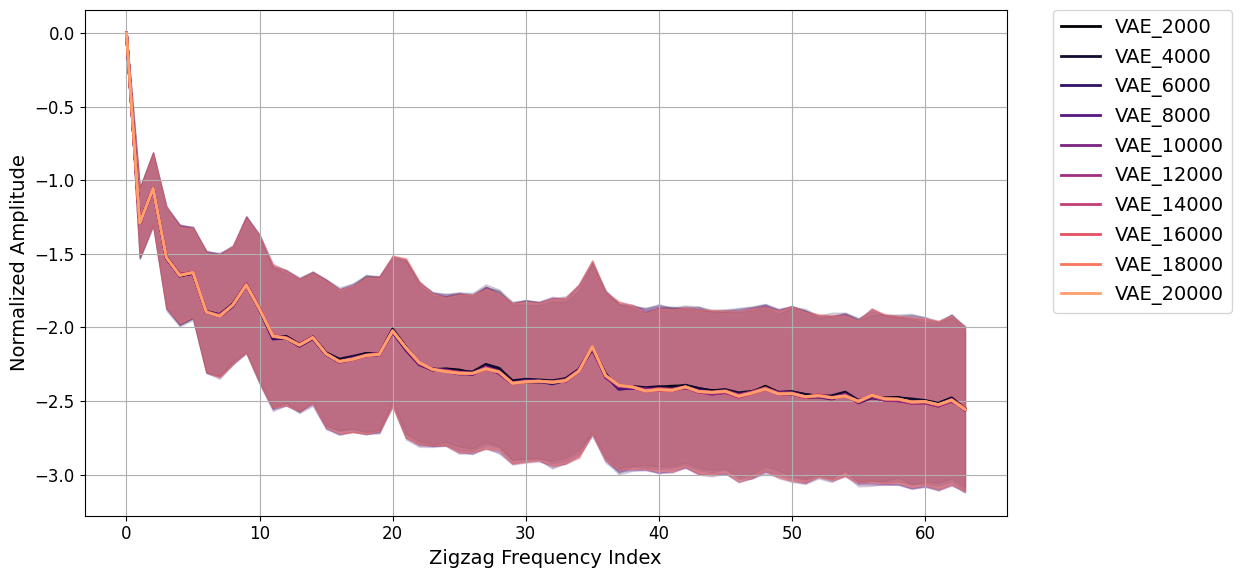

In [26]:
plot_spectrums_flat({k:np.log(s[2][:,0]) for k, s in spectrums.items()}, ylabel='Normalized Amplitude', plot_average=True, disable_color_grad=False, external_legend=True, figsize=(16,6), save_path='./fluxae-ch.png')